# 🧱 Part 15: Generation: From Logits to Text

> **Previous context**: Mini-GPT outputs logits. Generation decides how to choose the next token from those logits.
> **Goal for this part**: Compare greedy decoding, temperature sampling, top-k, top-p, and beam search.

Today we are solving one concrete confusion: what is the hidden mechanism behind this part of an LLM, and how can we rebuild it with small numbers before trusting a library?

## 0. Why decoding matters

The same model can sound deterministic, creative, repetitive, or diverse depending on the decoding rule.

## 1. Greedy and temperature

Greedy picks the highest-probability token. Temperature changes how sharp or flat the probability distribution is.

## 2. Top-k and top-p

Top-k keeps a fixed number of candidates. Top-p keeps enough candidates to cover a probability mass.

## 3. Beam search

Beam search keeps several candidate sequences, which can help structured tasks but may reduce open-ended diversity.

## How to use the code cells

Run the cells in order. The code is intentionally direct and small: each cell should expose one idea, print the key observation, and let you change a number to see what moves.

## Exercises

When a cell contains a TODO placeholder, fill it yourself and use the `assert` checks as feedback. You can ask an AI for hints, step-by-step reasoning, or a direction check, but avoid asking it to complete the exercise outright.

## Summary Checklist

- [ ] Decoding turns logits into token choices.
- [ ] Temperature controls randomness.
- [ ] Top-k, top-p, and beam search trade diversity, quality, and compute.

Next, continue through the code cells for the Inference part and inspect the printed observations.


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

torch.manual_seed(42)

In [2]:
def generate_greedy(model, input_ids, max_new_tokens=20, eos_id=None):
    'Read the values printed above and connect them to the concept in this cell.'
    model.eval()
    generated = input_ids.clone()
    
    with torch.no_grad():
        for _ in range(max_new_tokens):
            # Teaching note: follow this line to see the main step.
            logits = model(generated)  # [1, current_len, vocab_size]
            
            # Teaching note: follow this line to see the main step.
            next_logits = logits[0, -1, :]  # [vocab_size]
            
            # Teaching note: follow this line to see the main step.
            probs = F.softmax(next_logits, dim=-1)
            next_token = torch.argmax(probs, dim=-1, keepdim=True)  # [1]
            
            # Teaching note: follow this line to see the main step.
            generated = torch.cat([generated, next_token.unsqueeze(0)], dim=1)
            
            # Teaching note: follow this line to see the main step.
            if eos_id is not None and next_token.item() == eos_id:
                break
    
    return generated

print('Read the values printed above and connect them to the concept in this cell.')

Read the values printed above and connect them to the concept in this cell.

In [3]:
# Teaching note: follow this line to see the main step.
# Teaching note: follow this line to see the main step.
def make_pattern_data(num_samples=200, pattern_length=8):
    'Read the values printed above and connect them to the concept in this cell.'
    data = []
    for i in range(num_samples):
        seq = [(i + j) % pattern_length + 1 for j in range(pattern_length)]
        data.append(seq)
    return torch.tensor(data)

# Teaching note: follow this line to see the main step.
VOCAB_SIZE = 10
SEQ_LEN = 8

train_data = make_pattern_data(200, SEQ_LEN)
print(f"Training data shape: {train_data.shape}")
print(f"Read the values printed above and connect them to the concept in this cell.")
print(train_data[:3])
print(f"Read the values printed above and connect them to the concept in this cell.")

Training data shape: torch.Size([200, 8])Read the values printed above and connect them to the concept in this cell.tensor([[1, 2, 3, 4, 5, 6, 7, 8],
        [2, 3, 4, 5, 6, 7, 8, 1],
        [3, 4, 5, 6, 7, 8, 1, 2]])

Read the values printed above and connect them to the concept in this cell.

In [4]:
# Teaching note: follow this line to see the main step.
import torch.nn as nn

class SimpleGPT(nn.Module):
    def __init__(self, vocab_size, d_model=32, num_heads=2, num_layers=2):
        super().__init__()
        self.d_model = d_model
        self.token_emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb = nn.Embedding(64, d_model)  # Teaching note: follow this line to see the main step.
        self.blocks = nn.ModuleList([
            nn.TransformerEncoderLayer(
                d_model=d_model, nhead=num_heads, dim_feedforward=4*d_model,
                batch_first=True, activation='relu'
            )
            for _ in range(num_layers)
        ])
        self.lm_head = nn.Linear(d_model, vocab_size)
    
    def forward(self, x):
        batch, seq = x.shape
        positions = torch.arange(seq, device=x.device).unsqueeze(0).expand(batch, -1)
        x = self.token_emb(x) + self.pos_emb(positions)
        mask = nn.Transformer.generate_square_subsequent_mask(seq, device=x.device)
        for block in self.blocks:
            x = block(x, src_mask=mask, is_causal=True)
        return self.lm_head(x)

print('"SimpleGPT Definition complete！"')

SimpleGPT Definition complete!

In [5]:
# Teaching note: follow this line to see the main step.
model = SimpleGPT(VOCAB_SIZE, d_model=32, num_heads=2, num_layers=2)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

BATCH_SIZE = 16
NUM_EPOCHS = 30

print(f"training {NUM_EPOCHS}Read the values printed above and connect them to the concept in this cell.")
model.train()
for epoch in range(NUM_EPOCHS):
    total_loss = 0
    for i in range(0, len(train_data), BATCH_SIZE):
        batch = train_data[i:i+BATCH_SIZE]
        input_ids = batch[:, :-1]
        targets = batch[:, 1:]
        
        logits = model(input_ids)
        loss = F.cross_entropy(logits.reshape(-1, VOCAB_SIZE), targets.reshape(-1))
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:3d} | Loss: {total_loss:.4f}")

print('"Training finished！"')

Read the values printed above and connect them to the concept in this cell.Epoch   5 | Loss: 0.0184


Epoch  10 | Loss: 0.0093
Epoch  15 | Loss: 0.0058


Epoch  20 | Loss: 0.0040
Epoch  25 | Loss: 0.0029


Epoch  30 | Loss: 0.0022
Training finished!

In [6]:
# Teaching note: follow this line to see the main step.
# Teaching note: follow this line to see the main step.
prompt = torch.tensor([[1, 2]])  # Teaching note: follow this line to see the main step.

print(f"Prompt: {prompt.tolist()}")

# Teaching note: follow this line to see the main step.
result = generate_greedy(model, prompt, max_new_tokens=15)
print(f"Result:{result.tolist()}")

# Teaching note: follow this line to see the main step.
expected = [1, 2, 3, 4, 5, 6, 7, 8, 1, 2, 3, 4, 5, 6, 7, 8]
print(f"Read the values printed above and connect them to the concept in this cell.{expected[:len(result[0])]}")

correct = sum(1 for a, b in zip(result[0].tolist(), expected) if a == b)
print(f"Read the values printed above and connect them to the concept in this cell.{len(result[0])}Read the values printed above and connect them to the concept in this cell.{correct}/{len(result[0])}")

Prompt: [[1, 2]]
Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.

In [7]:
test_prompts = [
    [5],          # Teaching note: follow this line to see the main step.
    [3, 4],       # Teaching note: follow this line to see the main step.
    [8],          # Teaching note: follow this line to see the main step.
]

for prompt_tokens in test_prompts:
    prompt = torch.tensor([prompt_tokens])
    result = generate_greedy(model, prompt, max_new_tokens=10)
    print(f"Input {prompt_tokens}Read the values printed above and connect them to the concept in this cell.{result[0].tolist()}")

Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.

/var/folders/fv/xkn6r25n41j9fm98mh1l73hm0000gn/T/ipykernel_49842/3602924950.py:20: UserWarning: Glyph 23545 (\N{CJK UNIFIED IDEOGRAPH-5BF9}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/fv/xkn6r25n41j9fm98mh1l73hm0000gn/T/ipykernel_49842/3602924950.py:20: UserWarning: Glyph 27010 (\N{CJK UNIFIED IDEOGRAPH-6982}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/fv/xkn6r25n41j9fm98mh1l73hm0000gn/T/ipykernel_49842/3602924950.py:20: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/fv/xkn6r25n41j9fm98mh1l73hm0000gn/T/ipykernel_49842/3602924950.py:20: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/fv/xkn6r25n41j9fm98mh1l73hm0000gn/T/ipykernel_49842/3602924950.py:20: UserWarning: Glyph 24067 (\N{CJK UNIFIED IDEOGRAPH-5E03}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/fv/xkn6

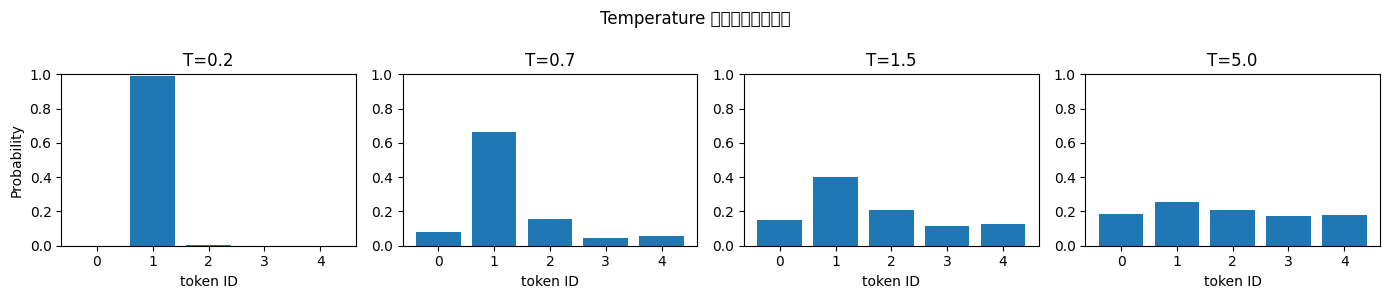

Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.

In [8]:
# Teaching note: follow this line to see the main step.
import matplotlib.pyplot as plt

# Teaching note: follow this line to see the main step.
example_logits = torch.tensor([0.5, 2.0, 1.0, 0.1, 0.3])

fig, axes = plt.subplots(1, 4, figsize=(14, 3))
temperatures = [0.2, 0.7, 1.5, 5.0]

for ax, T in zip(axes, temperatures):
    probs = F.softmax(example_logits / T, dim=-1)
    ax.bar(range(len(probs)), probs.numpy())
    ax.set_title(f'T={T}')
    ax.set_ylim(0, 1)
    ax.set_xlabel('token ID')
    if T == 0.2:
        ax.set_ylabel('Probability')

plt.suptitle('Read the values printed above and connect them to the concept in this cell.')
plt.tight_layout()
plt.show()

print('Read the values printed above and connect them to the concept in this cell.')
print('Read the values printed above and connect them to the concept in this cell.')
print('Read the values printed above and connect them to the concept in this cell.')


In [9]:
def generate_with_temperature(model, input_ids, max_new_tokens=20, 
                              temperature=1.0, top_k=None, eos_id=None):
    'Read the values printed above and connect them to the concept in this cell.'
    model.eval()
    generated = input_ids.clone()
    
    with torch.no_grad():
        for _ in range(max_new_tokens):
            logits = model(generated)
            raw_logits = logits[0, -1, :]

            if temperature <= 0:
                next_token = torch.argmax(raw_logits).unsqueeze(0)
                generated = torch.cat([generated, next_token.unsqueeze(0)], dim=1)
                if eos_id is not None and next_token.item() == eos_id:
                    break
                continue

            next_logits = raw_logits / temperature
            
            # Teaching note: follow this line to see the main step.
            if top_k is not None:
                top_k_values, _ = torch.topk(next_logits, top_k)
                min_top_k = top_k_values[-1]
                next_logits[next_logits < min_top_k] = float('-inf')
            
            # Teaching note: follow this line to see the main step.
            probs = F.softmax(next_logits, dim=-1)
            next_token = torch.multinomial(probs, num_samples=1)
            
            generated = torch.cat([generated, next_token.unsqueeze(0)], dim=1)
            
            if eos_id is not None and next_token.item() == eos_id:
                break
    
    return generated

print('Read the values printed above and connect them to the concept in this cell.')

Read the values printed above and connect them to the concept in this cell.

In [10]:
# Teaching note: follow this line to see the main step.
prompt = torch.tensor([[2]])

print('Read the values printed above and connect them to the concept in this cell.')
print()

for T in [0.1, 0.5, 1.0, 2.0]:
    torch.manual_seed(123)  # Teaching note: follow this line to see the main step.
    result = generate_with_temperature(model, prompt, max_new_tokens=10, temperature=T)
    print(f"T={T:.1f}: {result[0].tolist()}")

print(f"Read the values printed above and connect them to the concept in this cell.")
print(f"Read the values printed above and connect them to the concept in this cell.")

Read the values printed above and connect them to the concept in this cell.
T=0.1: [2, 3, 4, 5, 6, 7, 8, 1, 2, 3, 4]
T=0.5: [2, 3, 4, 5, 6, 7, 8, 1, 2, 3, 4]
T=1.0: [2, 3, 4, 5, 6, 7, 8, 1, 2, 3, 4]
T=2.0: [2, 3, 4, 5, 6, 7, 8, 1, 2, 3, 4]

Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.

In [11]:
# Teaching note: follow this line to see the main step.
prompt = torch.tensor([[2]])

print('Read the values printed above and connect them to the concept in this cell.')
print()

for k in [1, 3, 5, None]:
    torch.manual_seed(42)
    result = generate_with_temperature(
        model, prompt, max_new_tokens=10, temperature=0.7, top_k=k
    )
    label = f"top_k={k}" if k else "no top_k"
    
    # Teaching note: follow this line to see the main step.
    tokens = result[0].tolist()
    ok = all(tokens[i] == (tokens[i-1] % 8) + 1 for i in range(2, len(tokens)) if tokens[i-1] <= 8)
    status = 'Read the values printed above and connect them to the concept in this cell.' if ok else 'Read the values printed above and connect them to the concept in this cell.'
    
    print(f"{label:12s}: {tokens} {status}")

print(f"Read the values printed above and connect them to the concept in this cell.")
print(f"Read the values printed above and connect them to the concept in this cell.")
print(f"Read the values printed above and connect them to the concept in this cell.")

Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.

In [12]:
# Teaching note: follow this line to see the main step.
def top_p_filter(logits, p=0.9):
    sorted_logits, sorted_indices = torch.sort(logits, descending=True)
    cumulative_probs = torch.cumsum(torch.softmax(sorted_logits, dim=-1), dim=-1)
    sorted_indices_to_remove = cumulative_probs > p
    sorted_indices_to_remove[..., 0] = False
    indices_to_remove = sorted_indices[sorted_indices_to_remove]
    logits[:, indices_to_remove] = float('-inf')
    return logits

print('Read the values printed above and connect them to the concept in this cell.')
prompt = torch.tensor([[2]])
with torch.no_grad():
    logits = model(prompt)[0, -1, :]
probs = torch.softmax(logits, dim=-1)
sorted_probs, sorted_idx = torch.sort(probs, descending=True)
print('Read the values printed above and connect them to the concept in this cell.')
for i in range(10):
    print(f'  token {sorted_idx[i].item()}: {sorted_probs[i].item():.4f}')
print()
print('Read the values printed above and connect them to the concept in this cell.', sorted_idx[:3].tolist())
cumsum = torch.cumsum(sorted_probs, dim=-1)
n_top_p = (cumsum <= 0.9).sum().item() + 1
print(f'Read the values printed above and connect them to the concept in this cell.{sorted_idx[:n_top_p].tolist()}Read the values printed above and connect them to the concept in this cell.{n_top_p}Read the values printed above and connect them to the concept in this cell.')
print()
print('Read the values printed above and connect them to the concept in this cell.')

Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.  token 3: 0.9999
  token 4: 0.0000
  token 7: 0.0000
  token 1: 0.0000
  token 5: 0.0000
  token 6: 0.0000
  token 0: 0.0000
  token 9: 0.0000
  token 2: 0.0000
  token 8: 0.0000

Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.

In [13]:
def beam_search(model, input_ids, beam_size=3, max_new_tokens=10, eos_id=None):
    batch_size = input_ids.shape[0]
    beam_scores = torch.zeros(batch_size, beam_size)
    beam_sequences = input_ids.repeat(beam_size, 1)
    beam_done = [False] * beam_size
    for step in range(max_new_tokens):
        if all(beam_done):
            break
        with torch.no_grad():
            logits = model(beam_sequences)
        next_log_probs = torch.log_softmax(logits[:, -1, :], dim=-1)
        cumulative_scores = beam_scores[:, :1] + next_log_probs
        flat_scores = cumulative_scores.view(-1)
        top_scores, top_indices = torch.topk(flat_scores, beam_size)
        beam_indices = top_indices // logits.shape[-1]
        token_indices = top_indices % logits.shape[-1]
        new_beam_sequences, new_beam_scores, new_beam_done = [], [], []
        for i in range(beam_size):
            b_idx = beam_indices[i].item()
            t_idx = token_indices[i].item()
            if beam_done[b_idx]:
                new_beam_sequences.append(beam_sequences[b_idx])
                new_beam_scores.append(beam_scores[0, b_idx])
                new_beam_done.append(True)
            else:
                new_seq = torch.cat([beam_sequences[b_idx], token_indices[i].unsqueeze(0)])
                new_beam_sequences.append(new_seq)
                new_beam_scores.append(top_scores[i])
                new_beam_done.append(eos_id is not None and t_idx == eos_id)
        beam_sequences = torch.stack([s[:beam_sequences.shape[1]+1] for s in new_beam_sequences])
        beam_scores = torch.tensor(new_beam_scores).unsqueeze(0)
        beam_done = new_beam_done
    best_idx = beam_scores[0].argmax().item()
    return beam_sequences[best_idx].unsqueeze(0)

print("'Beam Search implementcomplete！'")
prompt = torch.tensor([[2]])
greedy_result = generate_with_temperature(model, prompt, max_new_tokens=8, temperature=0.0)
print(f'Greedy:      {greedy_result[0].tolist()}')
beam_result = beam_search(model, prompt, beam_size=3, max_new_tokens=8)
print(f'Beam (k=3):  {beam_result[0].tolist()}')

Beam Search implementcomplete!Greedy:      [2, 3, 4, 5, 6, 7, 8, 1, 2]
Beam (k=3):  [2, 3, 4, 5, 6, 7, 8, 1, 2]


In [14]:
def apply_repetition_penalty(logits, generated_ids, penalty=1.2):
    if penalty == 1.0:
        return logits
    for token_id in set(generated_ids.tolist()):
        score = logits[:, token_id]
        logits[:, token_id] = torch.where(score > 0, score / penalty, score * penalty)
    return logits

print('Read the values printed above and connect them to the concept in this cell.')
prompt = torch.tensor([[2]])
for penalty in [1.0, 1.2, 1.5]:
    generated = prompt.clone()
    with torch.no_grad():
        for _ in range(8):
            logits = model(generated)[0, -1, :].unsqueeze(0)
            logits = apply_repetition_penalty(logits, generated[0], penalty=penalty)
            probs = torch.softmax(logits / 0.7, dim=-1)
            next_token = torch.multinomial(probs, 1)
            generated = torch.cat([generated, next_token], dim=1)
    tokens = generated[0].tolist()
    unique_ratio = len(set(tokens)) / len(tokens)
    print(f'penalty={penalty:.1f}: {tokens}Read the values printed above and connect them to the concept in this cell.{unique_ratio:.1%})')
print()
print('Read the values printed above and connect them to the concept in this cell.')

Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.

In [15]:
def generate_full(model, input_ids, max_new_tokens=50, temperature=1.0,
                  top_k=None, top_p=None, repetition_penalty=1.0, eos_id=None):
    generated = input_ids.clone()
    for _ in range(max_new_tokens):
        with torch.no_grad():
            logits = model(generated)[0, -1, :].unsqueeze(0)
        if repetition_penalty != 1.0:
            logits = apply_repetition_penalty(logits, generated[0], repetition_penalty)
        logits = logits / temperature
        if top_k is not None:
            top_k_values, _ = torch.topk(logits, top_k)
            logits[logits < top_k_values[:, -1:]] = float('-inf')
        if top_p is not None:
            logits = top_p_filter(logits, top_p)
        probs = torch.softmax(logits, dim=-1)
        next_token = torch.multinomial(probs, 1)
        if eos_id is not None and next_token.item() == eos_id:
            break
        generated = torch.cat([generated, next_token], dim=1)
    return generated

print('Read the values printed above and connect them to the concept in this cell.')
print()
print('Read the values printed above and connect them to the concept in this cell.')
print('Read the values printed above and connect them to the concept in this cell.')
print('Read the values printed above and connect them to the concept in this cell.')
print('Read the values printed above and connect them to the concept in this cell.')
print('Read the values printed above and connect them to the concept in this cell.')
print('Read the values printed above and connect them to the concept in this cell.')

Read the values printed above and connect them to the concept in this cell.
Read the values printed above and connect them to the concept in this cell.  1. Read the values printed above and connect them to the concept in this cell.  2. Read the values printed above and connect them to the concept in this cell.  3. Read the values printed above and connect them to the concept in this cell.  4. Read the values printed above and connect them to the concept in this cell.  5. Read the values printed above and connect them to the concept in this cell.

---

### Part 6 Summary
1. .2. .3. .4. .5. Number of tokens: 6. .7. .8. .9. .
| Part |.|.|
|------|--------|-----------------|
| 1 Tokenizer |.|.|
| 2 BPE |.|.|
| 3 Embedding |.| nn.Embedding + Sinusoidal PE |
| 4 Attention |.| Scaled Dot-Product Attention |
| 5 Loss | teacher forcing + cross-entropy |.|
| 6 Generate |.|.|

1. .2. .3. .4. .5. .
---

.